# Additional filters based on contact area to the peptide and overall structure similarity among the backbones
**What's notably absent from your filters**
A few filters the paper uses that you haven't applied yet and that could further reduce your 369 before you even run MPNN:
- Peptide contact area quantification (CMS) — you have proximity, but have you computed actual contact molecular surface restricted to the peptide only? Backbones that are "near" the peptide but contact primarily the MHC scaffold are a known failure mode in this project specifically.
- Buried surface area / interface size — radius of gyration catches extended backbones but doesn't directly assess interface quality.
- Backbone diversity clustering — if many of your 369 are structurally very similar, you could cluster by backbone RMSD (e.g., at 1–2 Å) and take one representative per cluster before running MPNN. This avoids spending MPNN + AF2 compute on near-duplicate backbones.

Running these pre-MPNN could meaningfully reduce your 369 further and improve the quality of what enters the MPNN stage.

In [10]:
import pyrosetta
from pyrosetta import *
from pyrosetta.rosetta.core.scoring.sasa import SasaCalc
import glob
import pandas as pd

import numpy as np
from Bio import PDB
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

from os import symlink, makedirs
import os

init("-mute all -ignore_unrecognized_res true")

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org


## Compute CMS

In [3]:
def compute_peptide_buried_sasa(pdb_file):
    pose = pose_from_pdb(pdb_file)
    
    sasa_calc = SasaCalc()
    
    # --- SASA of full complex ---
    sasa_calc.calculate(pose)
    per_res_sasa_complex = list(sasa_calc.get_residue_sasa())
    
    # --- Identify chain C (peptide) residue indices ---
    peptide_residues = []
    for i in range(1, pose.total_residue() + 1):
        if pose.pdb_info().chain(i) == "C":
            peptide_residues.append(i)
    
    # --- SASA of peptide residues in complex ---
    peptide_sasa_bound = sum(per_res_sasa_complex[i-1] 
                             for i in peptide_residues)
    
    # --- SASA of peptide alone (delete all non-peptide residues) ---
    peptide_pose = pose.clone()
    
    # Delete residues not in chain C, in reverse order to preserve indices
    non_peptide = [i for i in range(1, pose.total_residue() + 1)
                   if pose.pdb_info().chain(i) != "C"]
    
    for i in reversed(non_peptide):
        peptide_pose.delete_residue_slow(i)
    
    sasa_calc.calculate(peptide_pose)
    per_res_sasa_free = list(sasa_calc.get_residue_sasa())
    peptide_sasa_free = sum(per_res_sasa_free)
    
    buried = peptide_sasa_free - peptide_sasa_bound
    return buried, peptide_sasa_free, peptide_sasa_bound

In [ ]:
results = []
pdb_files = sorted(glob.glob("~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/*.pdb"))
print(f"Processing {len(pdb_files)} backbones...")

for pdb in pdb_files:
    try:
        buried, free, bound = compute_peptide_buried_sasa(pdb)
        results.append({
            "pdb": pdb,
            "peptide_buried_sasa": buried,
            "peptide_sasa_free": free,
            "peptide_sasa_bound": bound,
            "fraction_buried": buried / free if free > 0 else 0
        })
    except Exception as e:
        print(f"  Failed: {pdb} — {e}")

df = pd.DataFrame(results).sort_values("peptide_buried_sasa", ascending=False)
df.to_csv("peptide_sasa_scores.csv", index=False)

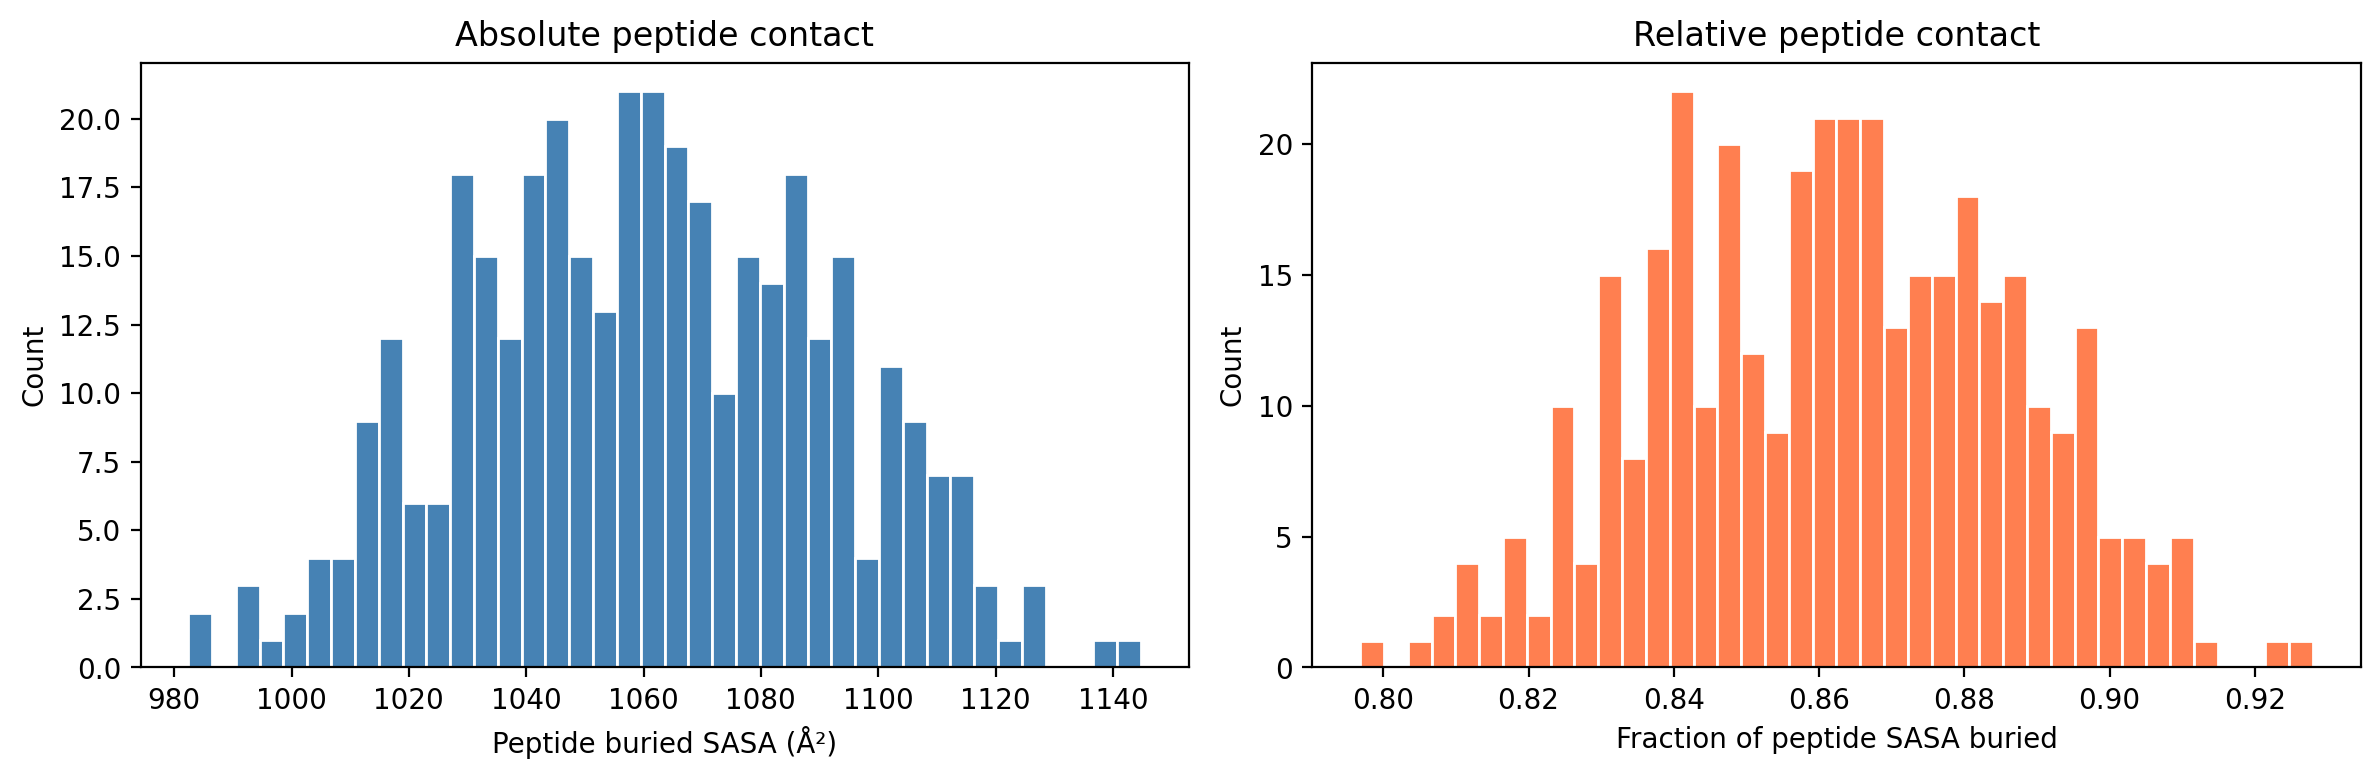


Stats:
       peptide_buried_sasa  fraction_buried
count           369.000000       369.000000
mean           1060.463310         0.862044
std              30.678136         0.024261
min             982.387410         0.796805
25%            1038.526251         0.843662
50%            1060.423703         0.862750
75%            1083.814140         0.880251
max            1144.795083         0.927982


In [3]:
df = pd.read_csv("peptide_sasa_scores.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["peptide_buried_sasa"], bins=40,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Peptide buried SASA (Å²)")
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute peptide contact")

axes[1].hist(df["fraction_buried"], bins=40,
             color="coral", edgecolor="white")
axes[1].set_xlabel("Fraction of peptide SASA buried")
axes[1].set_ylabel("Count")
axes[1].set_title("Relative peptide contact")

plt.tight_layout()
plt.savefig("peptide_sasa_distribution.png", dpi=150)
plt.show()

print("\nStats:")
print(df[["peptide_buried_sasa", "fraction_buried"]].describe())

**Conclusions:**

The fraction of peptide SASA buried is very high (0.8-0.93) and shows a continuous distribution (as opposed to bimodal) without outliers. This means that my earlier geometric filters (peptide contact, CoM distance, orientation) already did a good job ensuring real peptide engagement. No bimodal distribution with a population of "fake" contacts, which would have been the red flag.

All 369 backbones have substantial peptide contact. No need to trim based on SASA at all.

## Structure clustering
### Align on binder Cα atoms only and cluster

In [4]:
# --- Use all the backbones (all passed the SASA filter) ---
df_sasa = pd.read_csv("peptide_sasa_scores.csv")
pdb_files = df_sasa["pdb"].tolist()
print(f"Clustering {len(pdb_files)} backbones that passed SASA filter")

# --- Extract chain A Cα coordinates ---
def get_ca_coords(pdb_file, chain_id="A"):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("s", pdb_file)
    coords = []
    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                for residue in chain:
                    if "CA" in residue:
                        coords.append(residue["CA"].get_vector().get_array())
    return np.array(coords)

# --- RMSD after superposition ---
def compute_rmsd(coords1, coords2):
    min_len = min(len(coords1), len(coords2))
    if min_len == 0:
        return np.inf
    c1 = coords1[:min_len] - coords1[:min_len].mean(axis=0)
    c2 = coords2[:min_len] - coords2[:min_len].mean(axis=0)
    H = c1.T @ c2
    U, S, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    R = Vt.T @ np.diag([1, 1, d]) @ U.T
    c1_rot = c1 @ R.T
    return np.sqrt(((c1_rot - c2) ** 2).sum(axis=1).mean())

Clustering 369 backbones that passed SASA filter


Bin the backbones by length

In [5]:
records = []
all_coords = {}
for pdb in pdb_files:
    coords = get_ca_coords(pdb)
    length = len(coords)
    all_coords[pdb] = coords
    records.append({"pdb": pdb, "length": length})

df = pd.DataFrame(records)

# --- Define bins ---
bins = [(50, 64), (65, 79), (80, 94), (95, 109)]
bin_labels = ["50-64", "65-79", "80-94", "95-109"]

print("\nBackbone length distribution:")
print(df["length"].describe())
print("\nBackbones per bin:")
for (lo, hi), label in zip(bins, bin_labels):
    n = ((df["length"] >= lo) & (df["length"] <= hi)).sum()
    print(f"  {label} aa: {n} backbones")


Backbone length distribution:
count    369.000000
mean      79.951220
std       11.458233
min       52.000000
25%       71.000000
50%       81.000000
75%       89.000000
max      100.000000
Name: length, dtype: float64

Backbones per bin:
  50-64 aa: 39 backbones
  65-79 aa: 135 backbones
  80-94 aa: 147 backbones
  95-109 aa: 48 backbones



Bin 50-64 aa: 39 backbones
  Computing 741 pairwise RMSDs...
  RMSD range: 0.77 – 15.08 Å
  RMSD median: 4.90 Å
  Clusters at 2 Å: 34
  Representatives: 34

Bin 65-79 aa: 135 backbones
  Computing 9045 pairwise RMSDs...
    50/135 done
    100/135 done
  RMSD range: 0.34 – 23.25 Å
  RMSD median: 6.40 Å
  Clusters at 2 Å: 96
  Representatives: 96

Bin 80-94 aa: 147 backbones
  Computing 10731 pairwise RMSDs...
    50/147 done
    100/147 done
  RMSD range: 0.59 – 25.50 Å
  RMSD median: 13.54 Å
  Clusters at 2 Å: 132
  Representatives: 132

Bin 95-109 aa: 48 backbones
  Computing 1128 pairwise RMSDs...
  RMSD range: 1.73 – 24.58 Å
  RMSD median: 16.39 Å
  Clusters at 0 Å: 48
  Representatives: 48


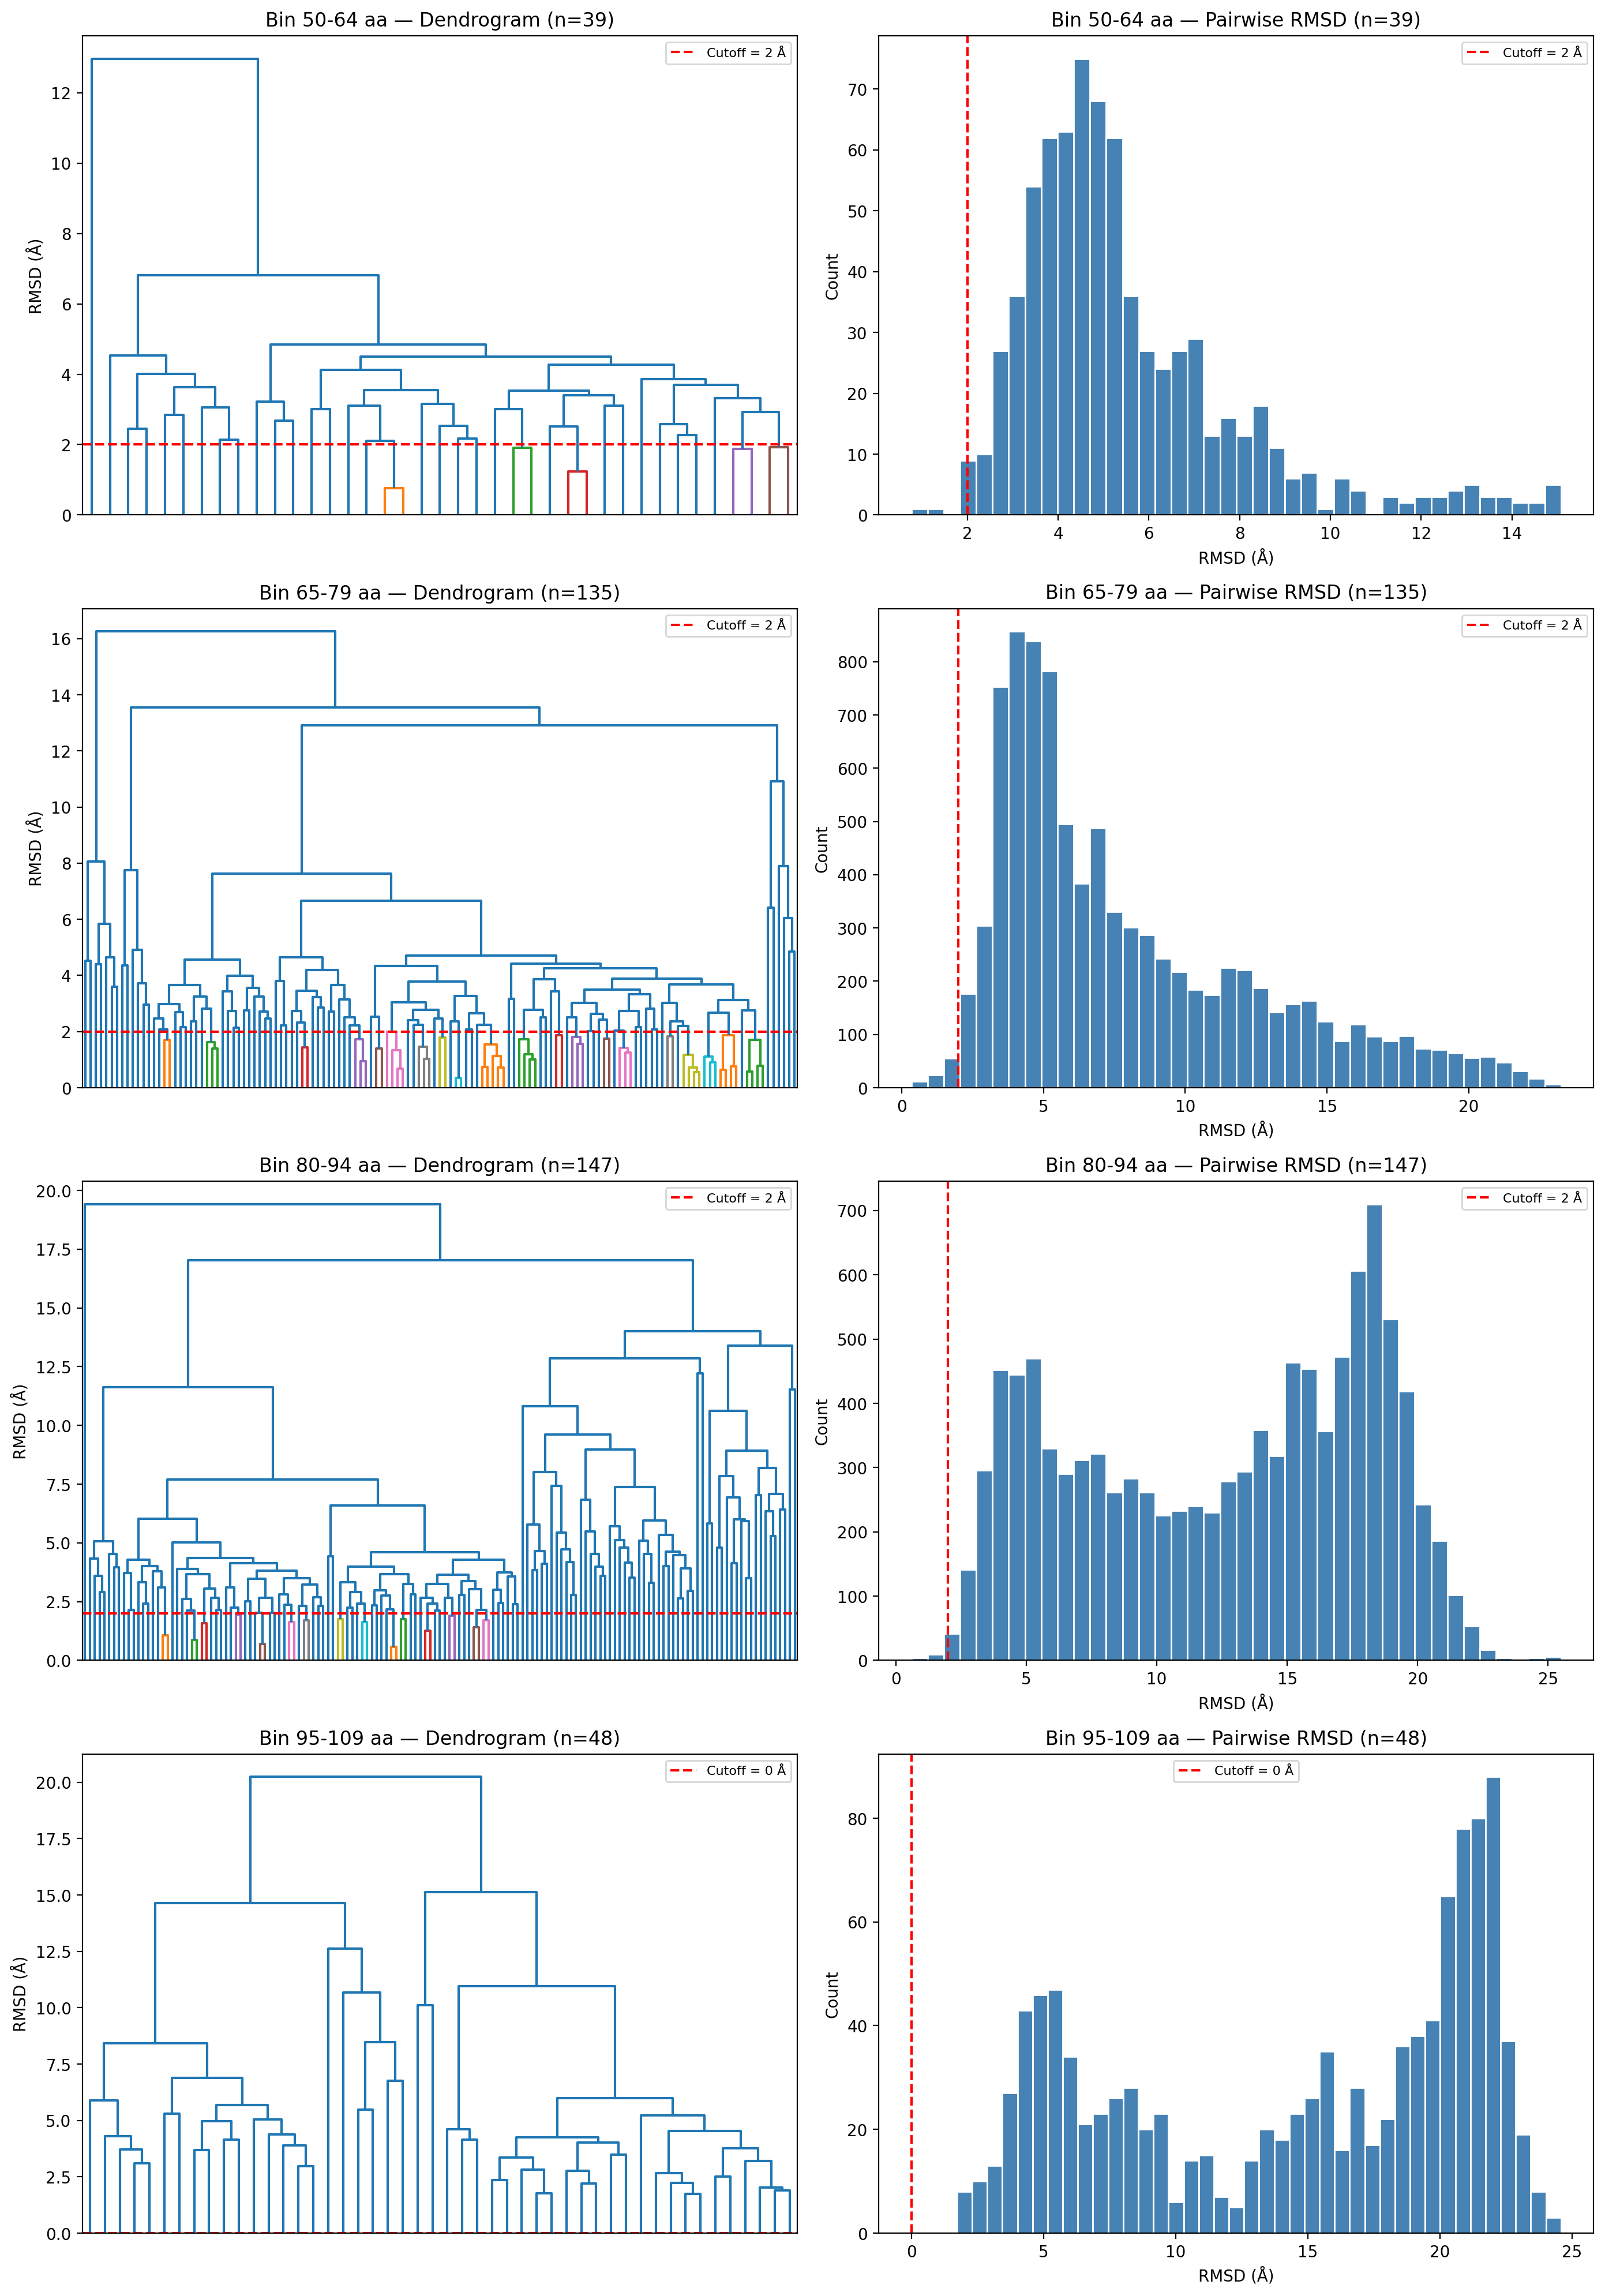


SUMMARY
  Total input backbones:     369
  Total representatives:     310
  Reduction:                 59 backbones removed

Outputs saved:
  backbone_clusters.csv  — full cluster assignments
  representatives.txt    — PDB paths to use for MPNN
  rmsd_matrix_bin_50-64.npy
  rmsd_matrix_bin_65-79.npy
  rmsd_matrix_bin_80-94.npy
  rmsd_matrix_bin_95-109.npy


In [7]:
# --- Cluster within each bin ---
all_representatives = []
all_cluster_records = []

rmsd_cutoff = 2  # Å — adjust after inspecting plots

# One figure with a row per bin
fig, axes = plt.subplots(len(bins), 2, figsize=(14, 5 * len(bins)))

for bin_idx, ((lo, hi), label) in enumerate(zip(bins, bin_labels)):
    
    if bin_idx == 3: # already diverse, no need to trim
        rmsd_cutoff = 0
    
    mask = (df["length"] >= lo) & (df["length"] <= hi)
    bin_pdbs = df[mask]["pdb"].tolist()
    n = len(bin_pdbs)
    
    print(f"\n{'='*50}")
    print(f"Bin {label} aa: {n} backbones")
    
    if n == 0:
        print("  Empty bin, skipping")
        axes[bin_idx, 0].set_visible(False)
        axes[bin_idx, 1].set_visible(False)
        continue
    
    if n == 1:
        print("  Single backbone, taking as representative")
        all_representatives.append(bin_pdbs[0])
        all_cluster_records.append({
            "pdb": bin_pdbs[0], 
            "bin": label, 
            "cluster": 1,
            "is_representative": True
        })
        axes[bin_idx, 0].set_visible(False)
        axes[bin_idx, 1].set_visible(False)
        continue

    # --- Pairwise RMSD ---
    print(f"  Computing {n*(n-1)//2} pairwise RMSDs...")
    rmsd_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            r = compute_rmsd(all_coords[bin_pdbs[i]], 
                             all_coords[bin_pdbs[j]])
            rmsd_matrix[i, j] = r
            rmsd_matrix[j, i] = r
        if i % 50 == 0 and i > 0:
            print(f"    {i}/{n} done")

    np.save(f"rmsd_matrix_bin_{label}.npy", rmsd_matrix)

    # --- Clustering ---
    condensed = squareform(rmsd_matrix)
    Z = linkage(condensed, method="average")
    labels_cluster = fcluster(Z, t=rmsd_cutoff, criterion="distance")

    # --- Representatives (medoids) ---
    bin_representatives = []
    for cluster_id in np.unique(labels_cluster):
        members = np.where(labels_cluster == cluster_id)[0].tolist()
        if len(members) == 1:
            rep_idx = members[0]
        else:
            sub_matrix = rmsd_matrix[np.ix_(members, members)]
            rep_idx = members[sub_matrix.mean(axis=1).argmin()]
        bin_representatives.append(bin_pdbs[rep_idx])
        
        for m in members:
            all_cluster_records.append({
                "pdb": bin_pdbs[m],
                "bin": label,
                "length": len(all_coords[bin_pdbs[m]]),
                "cluster": f"{label}_{cluster_id}",
                "is_representative": bin_pdbs[m] == bin_pdbs[rep_idx]
            })

    all_representatives.extend(bin_representatives)

    # --- Stats ---
    upper_tri = rmsd_matrix[np.triu_indices(n, k=1)]
    n_clusters = len(np.unique(labels_cluster))
    print(f"  RMSD range: {upper_tri.min():.2f} – {upper_tri.max():.2f} Å")
    print(f"  RMSD median: {np.median(upper_tri):.2f} Å")
    print(f"  Clusters at {rmsd_cutoff} Å: {n_clusters}")
    print(f"  Representatives: {len(bin_representatives)}")

    # --- Plots ---
    ax_dendro = axes[bin_idx, 0]
    ax_hist   = axes[bin_idx, 1]

    dendrogram(Z, ax=ax_dendro, no_labels=True, 
               color_threshold=rmsd_cutoff)
    ax_dendro.axhline(y=rmsd_cutoff, color="red", linestyle="--",
                      label=f"Cutoff = {rmsd_cutoff} Å")
    ax_dendro.set_title(f"Bin {label} aa — Dendrogram (n={n})")
    ax_dendro.set_ylabel("RMSD (Å)")
    ax_dendro.legend(fontsize=8)

    ax_hist.hist(upper_tri, bins=40, color="steelblue", edgecolor="white")
    ax_hist.axvline(x=rmsd_cutoff, color="red", linestyle="--",
                    label=f"Cutoff = {rmsd_cutoff} Å")
    ax_hist.set_title(f"Bin {label} aa — Pairwise RMSD (n={n})")
    ax_hist.set_xlabel("RMSD (Å)")
    ax_hist.set_ylabel("Count")
    ax_hist.legend(fontsize=8)

plt.tight_layout()
plt.savefig("clustering_summary_by_bin.png", dpi=150)
plt.show()

# --- Save outputs ---
df_clusters = pd.DataFrame(all_cluster_records)
df_clusters.to_csv("backbone_clusters.csv", index=False)

with open("representatives.txt", "w") as f:
    for pdb in all_representatives:
        f.write(pdb + "\n")

print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"  Total input backbones:     {len(pdb_files)}")
print(f"  Total representatives:     {len(all_representatives)}")
print(f"  Reduction:                 {len(pdb_files) - len(all_representatives)} backbones removed")
print(f"\nOutputs saved:")
print(f"  backbone_clusters.csv  — full cluster assignments")
print(f"  representatives.txt    — PDB paths to use for MPNN")
for (lo, hi), label in zip(bins, bin_labels):
    print(f"  rmsd_matrix_bin_{label}.npy")

Create a sym link for all representatives in a different directory

In [16]:
rep_dir = '~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/'
makedirs(rep_dir, exist_ok=True)

with open("representatives.txt", "r") as f:
    for lines in f:
        file_name = lines.rstrip()
        link_name = os.path.join(rep_dir, os.path.basename(file_name))
        try:
            symlink(file_name, link_name)
            print(f"Created symlink: {link_name} -> {file_name}")
        except FileExistsError:
            print("Link already exists")
        except OSError as e:
            print(f"Error: {e}")

Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_199.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_199.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_331.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_331.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_105.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_105.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_76.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_76.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiff

Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_20.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_20.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_275.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_275.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_160.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_160.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_221.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_221.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiff

Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_277.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_277.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_285.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_285.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_30.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_30.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_0.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_0.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusio

Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_287.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_287.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_355.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_355.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_86.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_86.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/rep/kras_orient_100.pdb -> ~/Desktop/pmhc_binder_kras/rfdiffusion/outputs/kras/1000_filtered/orientation_filtered/kras_orient_100.pdb
Created symlink: ~/Desktop/pmhc_binder_kras/rfdiff